## Q2. Unsupervised Learning

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/q2_customers.csv')

print(df.shape)
df.head

(500, 6)


<bound method NDFrame.head of      age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0     30         43075                 9         2080                     45   
1     19         14496                11          454                      8   
2     43         57632                 6         2144                     16   
3     30         15629                10          801                      0   
4     19         14901                16          396                     17   
..   ...           ...               ...          ...                    ...   
495   20         22094                13          729                      3   
496   53         63845                 1         7371                     30   
497   44         53558                 9          906                     10   
498   36         41202                 9         2046                     47   
499   20          8118                15          865                     16   

     num_

In [7]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


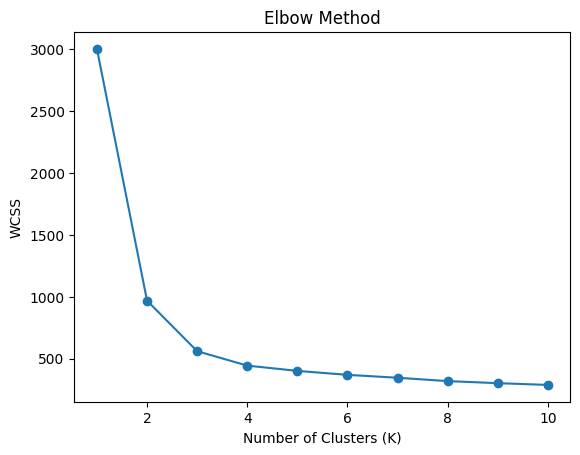

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [11]:
k_optimal = 5

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_df)

# Centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

print("Cluster Centroids:")
print(centroids)

df.head()

Cluster Centroids:
         age  annual_spend  visits_per_month  basket_size  \
0  24.833333  15219.166667         17.230769   543.397436   
1  56.552632  90136.644737          2.394737  5277.592105   
2  40.387879  43340.733333          8.193939  2021.684848   
3  56.955056  88795.674157          2.640449  5746.550562   
4  24.543478  14532.152174         11.891304   572.173913   

   days_since_last_visit  num_categories_purchased  
0               9.487179                  2.153846  
1             150.065789                  7.460526  
2              35.187879                  4.424242  
3              67.179775                  7.561798  
4               8.728261                  2.076087  


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,4
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,4
4,19,14901,16,396,17,1,0


In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

# Explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=scaled_df.columns,
    index=['PC1', 'PC2']
)

print("\nFeature Loadings:")
print(loadings)

Explained Variance Ratio:
[0.83560354 0.05568764]

Feature Loadings:
          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


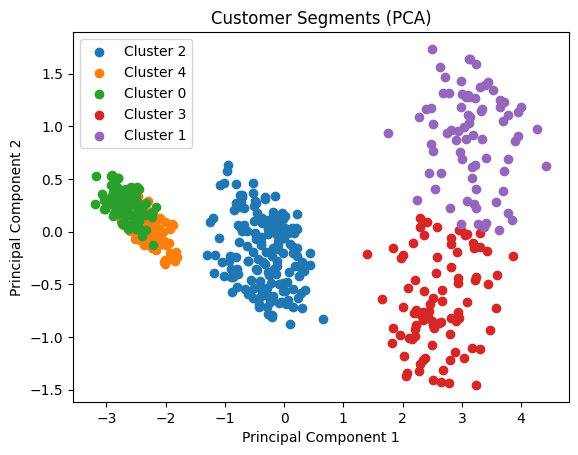

In [13]:
# Create DataFrame for plotting
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster']

# Plot
plt.figure()

for cluster in pca_df['cluster'].unique():
    subset = pca_df[pca_df['cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}')

plt.title('Customer Segments (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()